# Import Libraries

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import seaborn as sns

# Load Dataset

In [18]:
df = pd.read_csv('/content/weather.csv')
df.head()

,Data.Precipitation,Date.Full,Date.Month,Date.Week of,Date.Year,Station.City,Station.Code,Station.Location,Station.State,Data.Temperature.Avg Temp,Data.Temperature.Max Temp,Data.Temperature.Min Temp,Data.Wind.Direction,Data.Wind.Speed
0,0.00,2016-01-03,1,3,2016,Birmingham,BHM,"Birmingham, AL",Alabama,39,46,32,33,4.33
1,0.00,2016-01-03,1,3,2016,Huntsville,HSV,"Huntsville, AL",Alabama,39,47,31,32,3.86
2,0.16,2016-01-03,1,3,2016,Mobile,MOB,"Mobile, AL",Alabama,46,51,41,35,9.73
3,0.00,2016-01-03,1,3,2016,Montgomery,MGM,"Montgomery, AL",Alabama,45,52,38,32,6.86
4,0.01,2016-01-03,1,3,2016,Anchorage,ANC,"Anchorage, AK",Alaska,34,38,29,19,7.80


# Check Missing

In [21]:
df.isnull().sum()

,0
Data.Precipitation,0
Date.Full,0
Date.Month,0
Date.Week of,0
Date.Year,0
Station.City,0
Station.Code,0
Station.Location,0
Station.State,0
Data.Temperature.Avg Temp,0


In [22]:
df.drop_duplicates(inplace=True)

In [24]:
df['Date.Full'] = pd.to_datetime(df['Date.Full'])
df.set_index('Date.Full', inplace=True)

# Visualize EDA

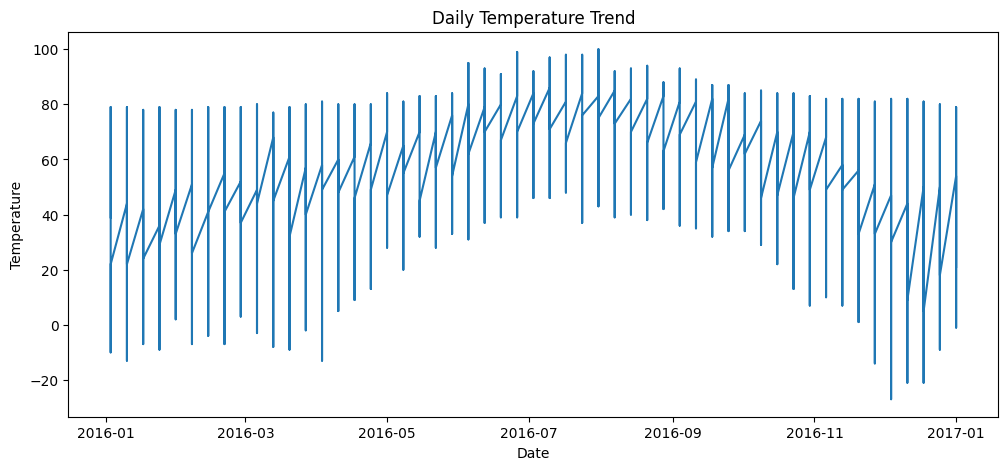

In [26]:
plt.figure(figsize=(12,5))
plt.plot(df['Data.Temperature.Avg Temp'])
plt.title("Daily Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

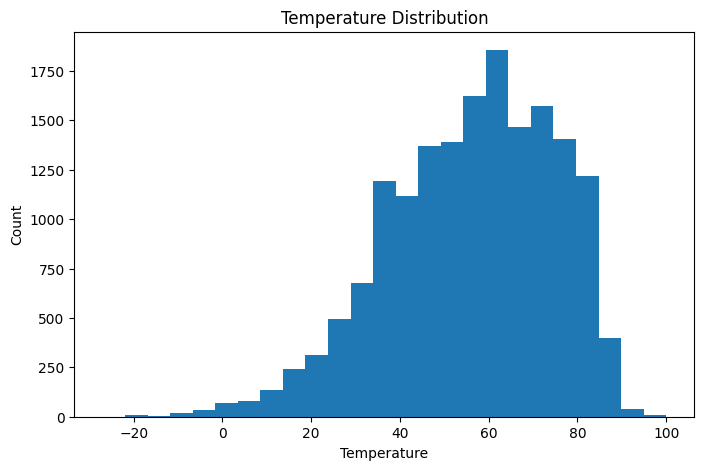

In [28]:
plt.figure(figsize=(8,5))
plt.hist(df['Data.Temperature.Avg Temp'], bins=25)
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Count")
plt.show()

# Box plot for Outliers

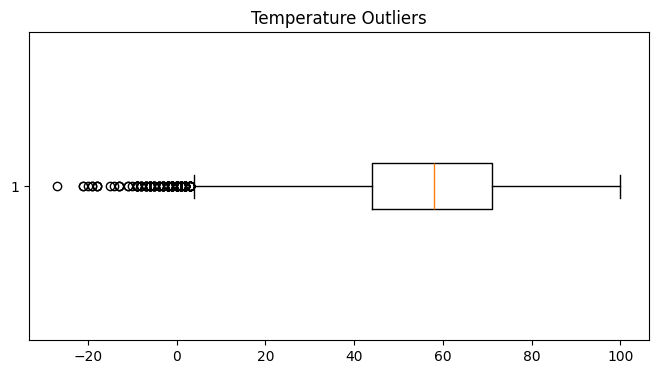

In [30]:
plt.figure(figsize=(8,4))
plt.boxplot(df['Data.Temperature.Avg Temp'], vert=False)
plt.title("Temperature Outliers")
plt.show()

# Monthly Average Temperature

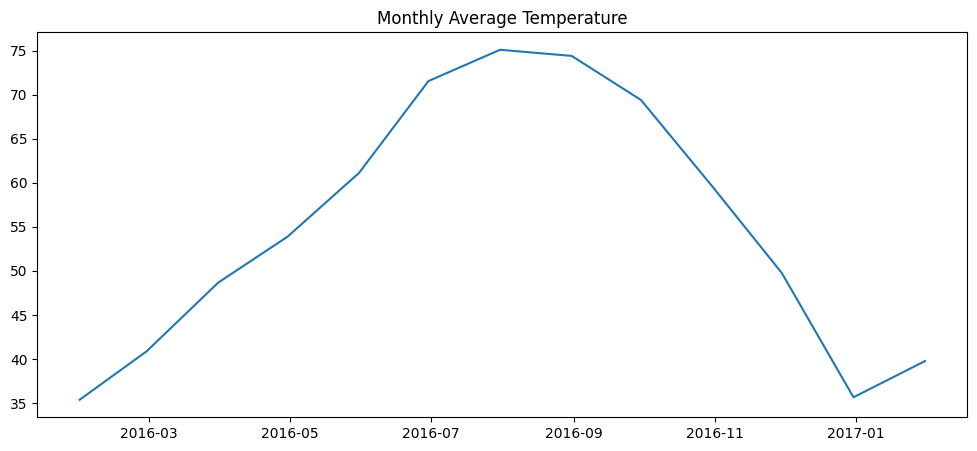

In [34]:
monthly_avg = df['Data.Temperature.Avg Temp'].resample('ME').mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_avg)
plt.title("Monthly Average Temperature")
plt.show()

# Rolling Mean

# Use Temperature Column

In [36]:
data = df[['Data.Temperature.Avg Temp']].values

# Scale Data

In [37]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create Sequences

In [38]:
X = []
y = []

for i in range(7, len(scaled_data)):
    X.append(scaled_data[i-7:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape(X.shape[0], X.shape[1], 1)

# Split Data

In [39]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Build LSTM Model

In [40]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(7,1)))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Train Model

In [41]:
history = model.fit(X_train, y_train,
                    epochs=30,
                    batch_size=16,
                    validation_data=(X_test, y_test))

Epoch 1/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0130 - val_loss: 0.0099
Epoch 2/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0078 - val_loss: 0.0086
Epoch 3/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0066 - val_loss: 0.0083
Epoch 4/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0059 - val_loss: 0.0075
Epoch 5/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0055 - val_loss: 0.0077
Epoch 6/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0051 - val_loss: 0.0078
Epoch 7/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0049 - val_loss: 0.0078
Epoch 8/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0047 - val_loss: 0.0073
Epoch 9/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0046 - val_loss: 0.0074
Epoch 10/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0045 - val_loss: 0.0073
Epoch 11/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0045 - val_loss: 0.0077
Epoch 12/30
837/837 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/s

# Correlation Heatmap

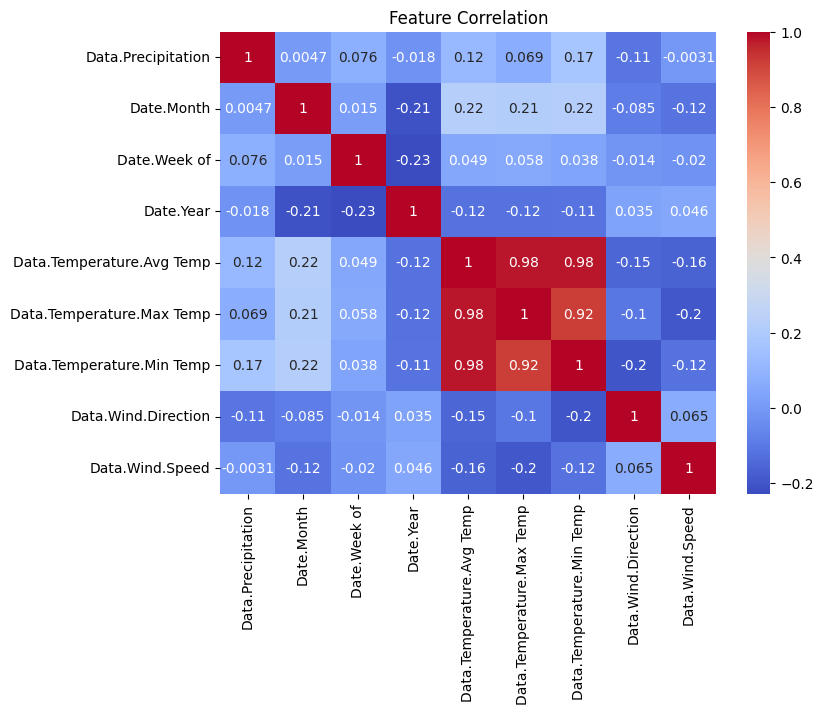

In [42]:


plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# Training Loss vs Validation Loss

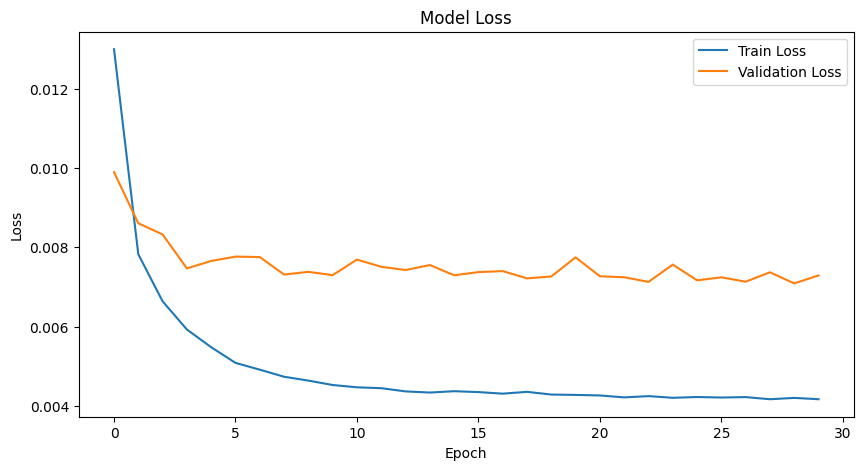

In [43]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#  Predict

In [44]:
pred = model.predict(X_test)

pred = scaler.inverse_transform(pred.reshape(-1,1))
real = scaler.inverse_transform(y_test.reshape(-1,1))

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


# Prediction Error Charts

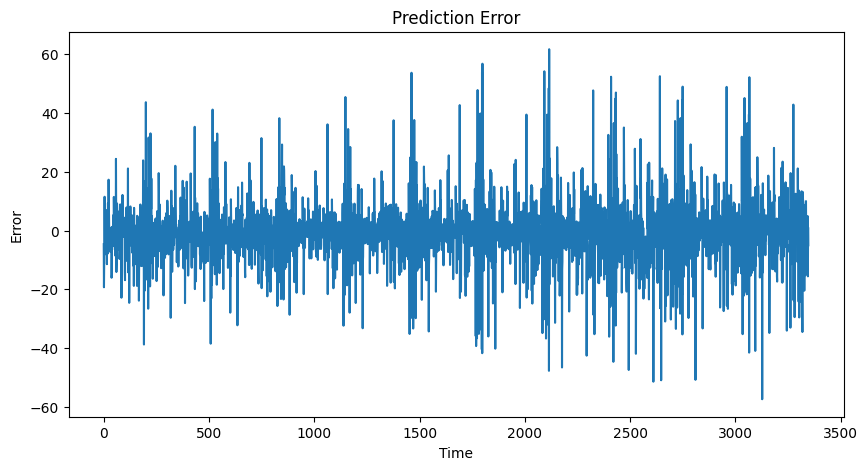

In [45]:
error = real.flatten() - pred.flatten()

plt.figure(figsize=(10,5))
plt.plot(error)
plt.title("Prediction Error")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()

# Plot Results

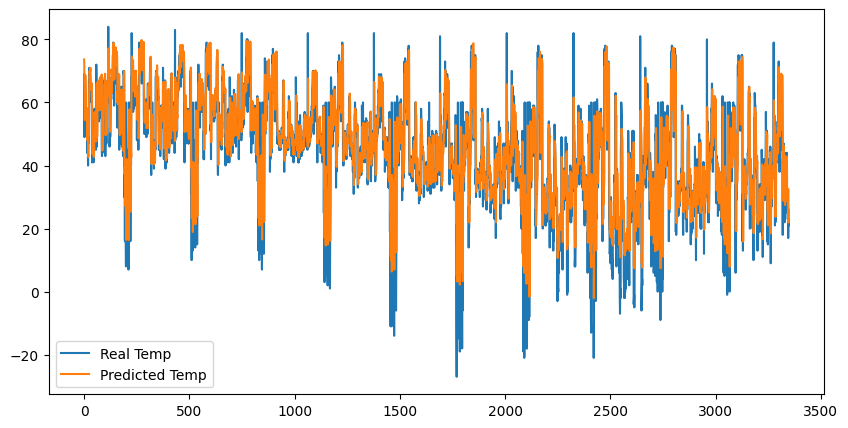

In [46]:
plt.figure(figsize=(10,5))
plt.plot(real, label='Real Temp')
plt.plot(pred, label='Predicted Temp')
plt.legend()
plt.show()